### 1. Basic Dataset Overview ###
Shape: (122, 84)

Missing Values Per Column (Top 10):
follow_ups_days_to_recurrence                          120
demographic_days_to_death                              119
follow_ups_days_to_progression                         118
diagnoses_tumor_of_origin                              117
follow_ups_progression_or_recurrence                   117
follow_ups_progression_or_recurrence_anatomic_site     117
follow_ups_progression_or_recurrence_type              117
follow_ups_molecular_tests_copy_number                 112
follow_ups_molecular_tests_cell_count                  111
follow_ups_molecular_tests_staining_intensity_scale    103
dtype: int64


C:\Users\USER\AppData\Local\Temp\ipykernel_19924\3102082404.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='demographic_gender', ax=axes[0], palette='viridis')
C:\Users\USER\AppData\Local\Temp\ipykernel_19924\3102082404.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='demographic_vital_status', ax=axes[2], palette='magma')


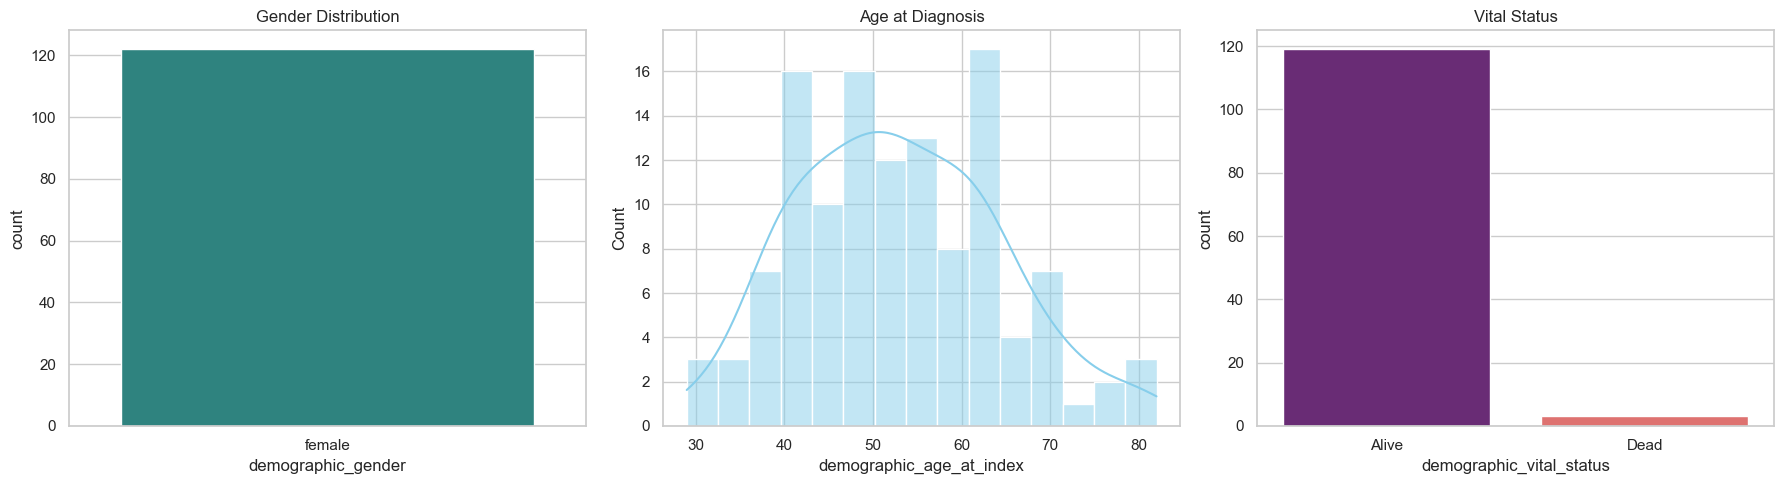

C:\Users\USER\AppData\Local\Temp\ipykernel_19924\3102082404.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='diagnoses_ajcc_pathologic_stage', order=order, palette='Set2')


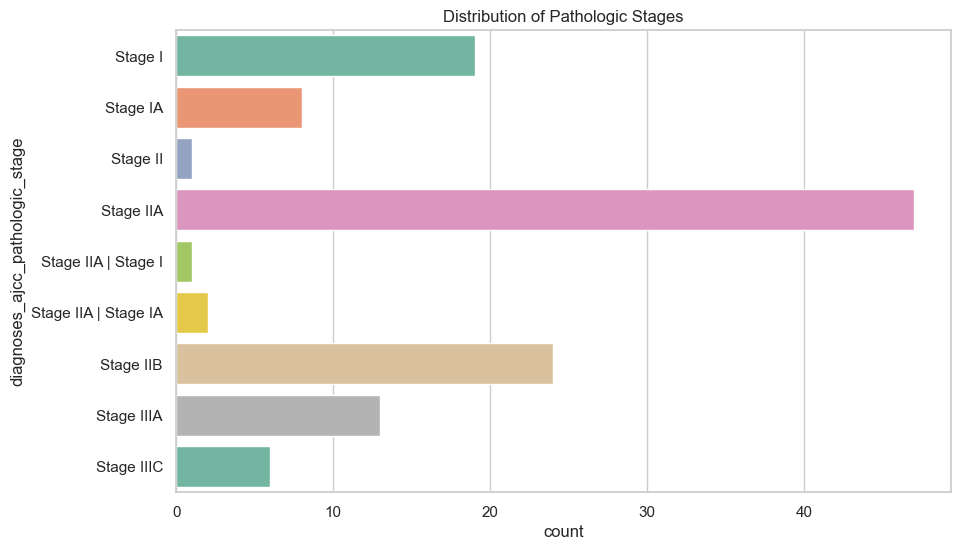

C:\Users\USER\AppData\Local\Temp\ipykernel_19924\3102082404.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='primary_gene', palette='rocket')


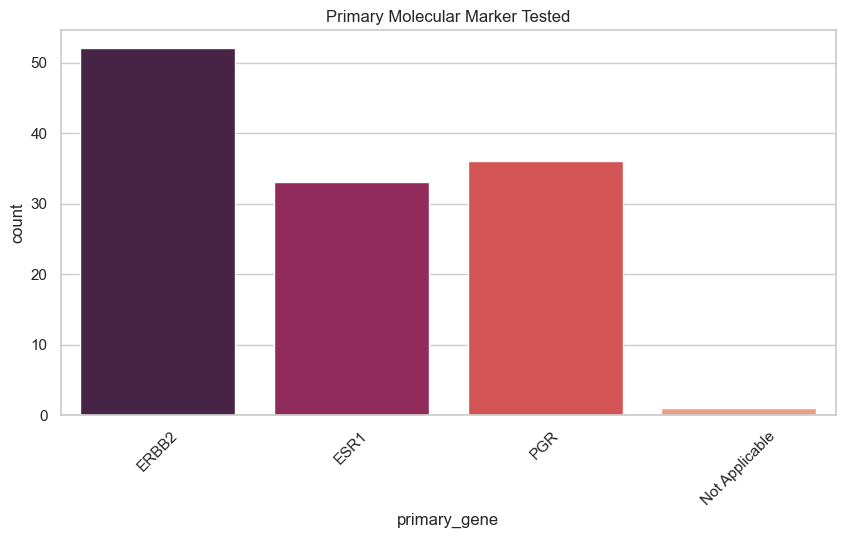

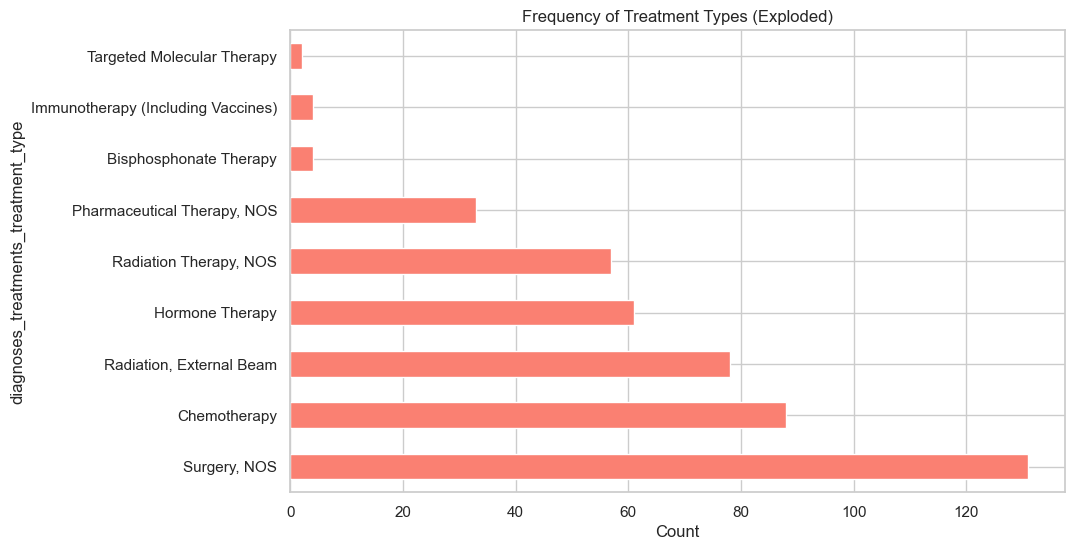

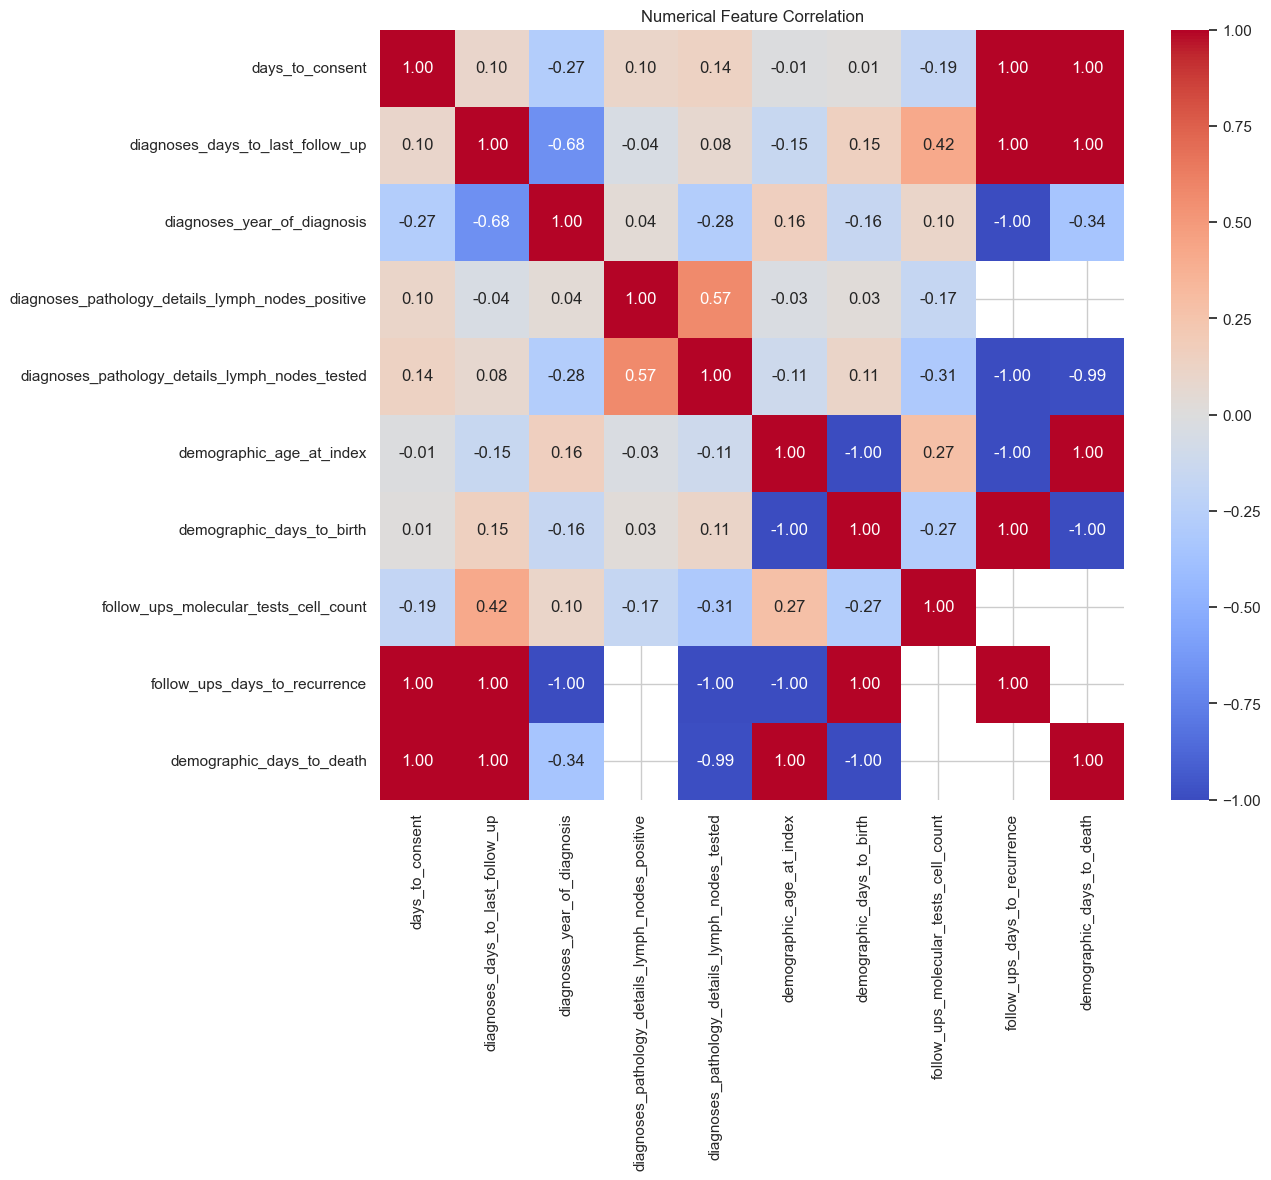


### 3. Clinical Insights ###

Average Age by Menopause Status:
follow_ups_other_clinical_attributes_menopause_status
Perimenopausal    49.666667
Postmenopausal    61.262295
Premenopausal     42.791667
Unknown           49.666667
Name: demographic_age_at_index, dtype: float64


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Load the dataset
# Assuming the file is named 'clinical_demographic_data.csv'
df = pd.read_csv('D:\\TCGA-BRCA\\Uploading\\Clinical_Demographic_Data.csv')

def perform_eda(df):
    print("### 1. Basic Dataset Overview ###")
    print(f"Shape: {df.shape}")
    print("\nMissing Values Per Column (Top 10):")
    print(df.isnull().sum().sort_values(ascending=False).head(10))
    
    # --- 2. Demographics Analysis ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    sns.countplot(data=df, x='demographic_gender', ax=axes[0], palette='viridis')
    axes[0].set_title('Gender Distribution')
    
    sns.histplot(df['demographic_age_at_index'], bins=15, kde=True, ax=axes[1], color='skyblue')
    axes[1].set_title('Age at Diagnosis')
    
    sns.countplot(data=df, x='demographic_vital_status', ax=axes[2], palette='magma')
    axes[2].set_title('Vital Status')
    plt.tight_layout()
    plt.show()

    # --- 3. Pathological Staging ---
    plt.figure(figsize=(10, 6))
    order = sorted(df['diagnoses_ajcc_pathologic_stage'].dropna().unique())
    sns.countplot(data=df, y='diagnoses_ajcc_pathologic_stage', order=order, palette='Set2')
    plt.title('Distribution of Pathologic Stages')
    plt.show()

    # --- 4. Molecular Markers Analysis (Handling Piped Values) ---
    # Many values are "ERBB2 | PGR | ESR1". Let's see the primary gene listed.
    df['primary_gene'] = df['follow_ups_molecular_tests_gene_symbol'].str.split('|').str[0].str.strip()
    
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x='primary_gene', palette='rocket')
    plt.title('Primary Molecular Marker Tested')
    plt.xticks(rotation=45)
    plt.show()

    # --- 5. Treatment Analysis ---
    # Splitting the piped treatment types to see what's most common
    all_treatments = df['diagnoses_treatments_treatment_type'].str.split('|').explode().str.strip()
    
    plt.figure(figsize=(10, 6))
    all_treatments.value_counts().plot(kind='barh', color='salmon')
    plt.title('Frequency of Treatment Types (Exploded)')
    plt.xlabel('Count')
    plt.show()

    # --- 6. Correlation Heatmap (Numerical Only) ---
    plt.figure(figsize=(12, 10))
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    # Filter out columns with all NaNs
    numeric_cols = [c for c in numeric_cols if df[c].nunique() > 1]
    sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Numerical Feature Correlation')
    plt.show()

    # --- 7. Specialized Insights ---
    print("\n### 3. Clinical Insights ###")
    # Average age by Menopause Status
    if 'follow_ups_other_clinical_attributes_menopause_status' in df.columns:
        menopause_age = df.groupby('follow_ups_other_clinical_attributes_menopause_status')['demographic_age_at_index'].mean()
        print("\nAverage Age by Menopause Status:")
        print(menopause_age)

# Run the EDA
perform_eda(df)

C:\Users\USER\AppData\Local\Temp\ipykernel_19924\2643556415.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='clean_stage', y='age', palette='vlag', ax=axes[0,0])
C:\Users\USER\AppData\Local\Temp\ipykernel_19924\2643556415.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=treatments, palette='rocket', ax=axes[1,0])


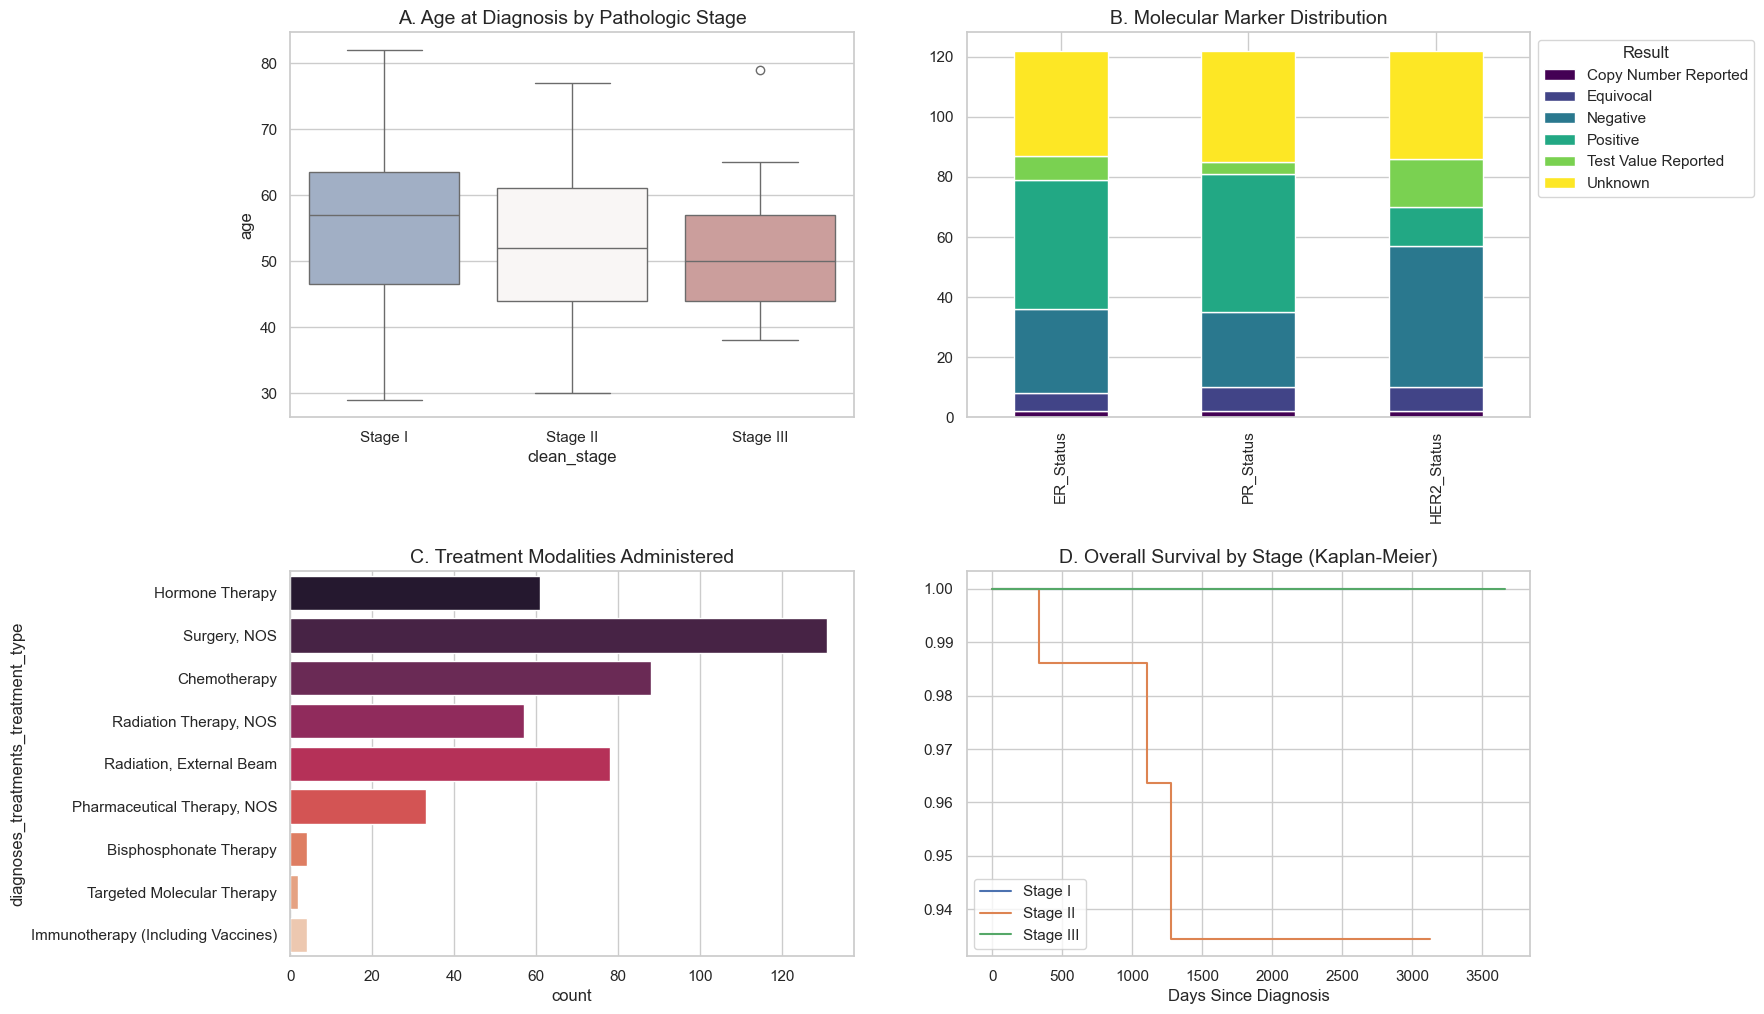

--- CLINICAL COHORT SUMMARY ---
               age clean_stage demographic_vital_status
count   122.000000         121                      122
unique         NaN           3                        2
top            NaN    Stage II                    Alive
freq           NaN          75                      119
mean     52.901639         NaN                      NaN
std      11.341003         NaN                      NaN
min      29.000000         NaN                      NaN
25%      44.250000         NaN                      NaN
50%      52.000000         NaN                      NaN
75%      61.000000         NaN                      NaN
max      82.000000         NaN                      NaN


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# 1. LOAD & INITIAL CLEANING
df = pd.read_csv('D:\\TCGA-BRCA\\Uploading\\Clinical_Demographic_Data.csv')

def get_first_val(x):
    if pd.isna(x): return np.nan
    return str(x).split('|')[0].strip()

# Create a clean version of the stage (e.g., Stage IIA -> Stage II)
df['clean_stage'] = df['diagnoses_ajcc_pathologic_stage'].str.extract(r'(Stage [IV]+)')
df['age'] = df['demographic_age_at_index']

# 2. MOLECULAR SUBTYPING (Crucial for Breast Cancer Research)
# We need to extract ER, PR, and HER2 status from the piped molecular columns
def extract_marker_status(row, marker_name):
    try:
        genes = str(row['follow_ups_molecular_tests_gene_symbol']).split('|')
        results = str(row['follow_ups_molecular_tests_test_result']).split('|')
        gene_map = dict(zip([g.strip() for g in genes], [r.strip() for r in results]))
        return gene_map.get(marker_name, "Unknown")
    except:
        return "Unknown"

df['ER_Status'] = df.apply(lambda x: extract_marker_status(x, 'ESR1'), axis=1)
df['PR_Status'] = df.apply(lambda x: extract_marker_status(x, 'PGR'), axis=1)
df['HER2_Status'] = df.apply(lambda x: extract_marker_status(x, 'ERBB2'), axis=1)

# 3. RESEARCH VISUALIZATION SUITE
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.4)

# Plot A: Age Distribution by Stage
sns.boxplot(data=df, x='clean_stage', y='age', palette='vlag', ax=axes[0,0])
axes[0,0].set_title('A. Age at Diagnosis by Pathologic Stage', fontsize=14)

# Plot B: Molecular Profile (Hormone Receptor Status)
marker_counts = df[['ER_Status', 'PR_Status', 'HER2_Status']].apply(pd.Series.value_counts).T
marker_counts.plot(kind='bar', stacked=True, ax=axes[0,1], colormap='viridis')
axes[0,1].set_title('B. Molecular Marker Distribution', fontsize=14)
axes[0,1].legend(title="Result", bbox_to_anchor=(1,1))

# Plot C: Treatment Frequency (Parsing the Pipes)
treatments = df['diagnoses_treatments_treatment_type'].str.split('|').explode().str.strip()
sns.countplot(y=treatments, palette='rocket', ax=axes[1,0])
axes[1,0].set_title('C. Treatment Modalities Administered', fontsize=14)

# Plot D: Survival Analysis (Kaplan-Meier)
kmf = KaplanMeierFitter()
# TCGA: If death days is NaN, use last follow up
df['duration'] = df['demographic_days_to_death'].fillna(df['diagnoses_days_to_last_follow_up'])
df['event'] = df['demographic_vital_status'].map({'Dead': 1, 'Alive': 0})

for stage in df['clean_stage'].dropna().unique():
    mask = (df['clean_stage'] == stage)
    kmf.fit(df[mask]['duration'], df[mask]['event'], label=stage)
    kmf.plot_survival_function(ax=axes[1,1], ci_show=False)

axes[1,1].set_title('D. Overall Survival by Stage (Kaplan-Meier)', fontsize=14)
axes[1,1].set_xlabel('Days Since Diagnosis')
plt.show()

# 4. STATISTICAL SUMMARY FOR PAPER
print("--- CLINICAL COHORT SUMMARY ---")
print(df[['age', 'clean_stage', 'demographic_vital_status']].describe(include='all'))

Total events (deaths) captured: 0


C:\Users\USER\AppData\Local\Temp\ipykernel_19924\745884508.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=valid_age_df, x='Subtype', y='age_at_diagnosis', ax=ax1, alpha=0.6, jitter=True, palette="Dark2")


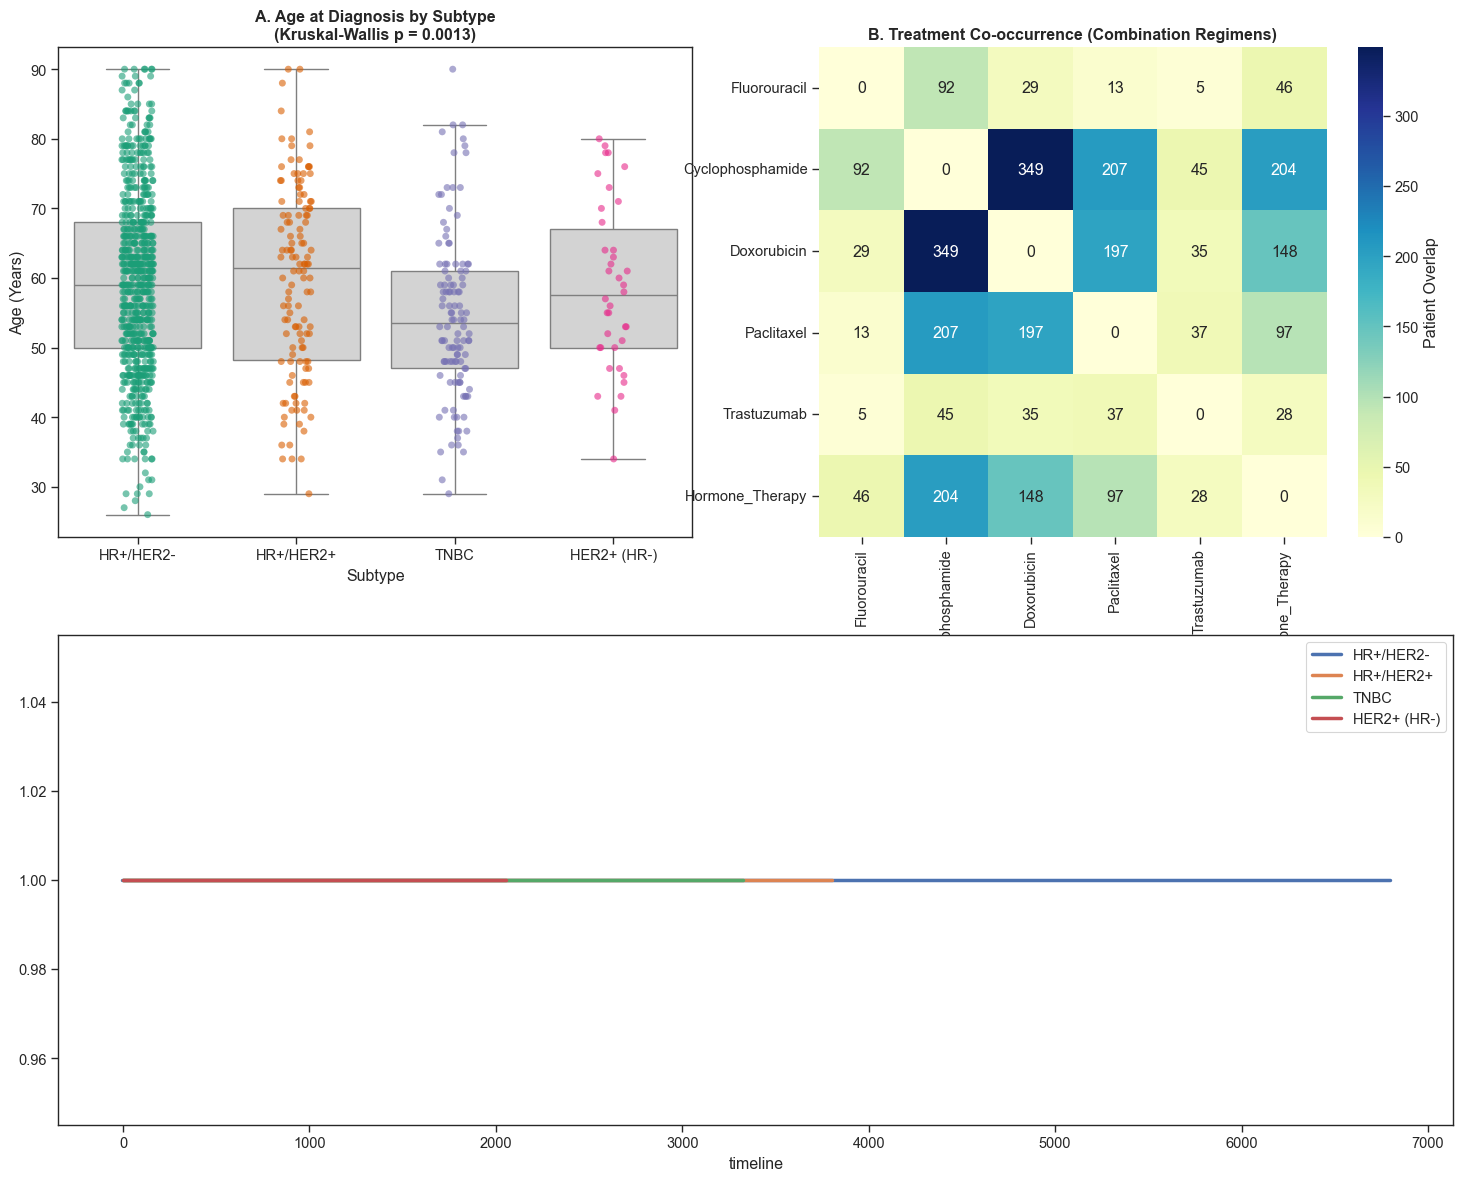

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test

# 1. High-End Visual Setup for Publications
sns.set_theme(style="ticks", context="paper", font_scale=1.2)
plt.rcParams['figure.figsize'] = (16, 12)

# 1. Load the Data
df = pd.read_csv('D:\\TCGA-BRCA\\Uploading\\Clinical_Treatment_Data.csv')

# --- DATA PREPARATION ---
# Clean vital status robustly (handles 'Dead', 'DEAD', 'Deceased', etc.)
df['vital_status_clean'] = df['vital_status'].astype(str).str.strip().str.lower()
df['event_observed'] = df['vital_status_clean'].apply(lambda x: 1 if x in ['dead', 'deceased'] else 0)

# Clean Drug Columns (Same logic as before, creating grouped binary columns)
drug_mappings = {
    'Fluorouracil': [c for c in df.columns if 'fluoro' in c.lower() or '5-fu' in c.lower()],
    'Cyclophosphamide': [c for c in df.columns if 'cyclo' in c.lower() or 'cytoxan' in c.lower()],
    'Doxorubicin': [c for c in df.columns if 'doxorubicin' in c.lower() or 'adriamycin' in c.lower()],
    'Paclitaxel': [c for c in df.columns if 'paclitaxel' in c.lower() or 'taxol' in c.lower()],
    'Trastuzumab': [c for c in df.columns if 'trastuzumab' in c.lower() or 'herceptin' in c.lower()],
    'Hormone_Therapy': [c for c in df.columns if 'tamoxifen' in c.lower() or 'letrozole' in c.lower() or 'anastrozole' in c.lower()]
}
for new_col, old_cols in drug_mappings.items():
    df[new_col] = df[old_cols].sum(axis=1).apply(lambda x: 1 if x > 0 else 0)

# Define Clinical Subtypes
def determine_subtype(row):
    er, pr, her2 = str(row['er_status_by_ihc']).lower(), str(row['pr_status_by_ihc']).lower(), str(row['her2_status_by_ihc']).lower()
    if 'positive' in er or 'positive' in pr:
        return 'HR+/HER2-' if her2 != 'positive' else 'HR+/HER2+' # Luminal A/B vs Triple Positive
    elif her2 == 'positive':
        return 'HER2+ (HR-)'
    elif er == 'negative' and pr == 'negative' and her2 == 'negative':
        return 'TNBC'
    return 'Unknown'

df['Subtype'] = df.apply(determine_subtype, axis=1)

# --- VISUALIZATION SUITE ---
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(2, 2)

# Plot A: Age vs Subtype with Swarm Overlay and Kruskal-Wallis Test
ax1 = fig.add_subplot(gs[0, 0])
valid_age_df = df.dropna(subset=['age_at_diagnosis', 'Subtype'])
valid_age_df = valid_age_df[valid_age_df['Subtype'] != 'Unknown']

sns.boxplot(data=valid_age_df, x='Subtype', y='age_at_diagnosis', ax=ax1, color="lightgray", showfliers=False)
sns.stripplot(data=valid_age_df, x='Subtype', y='age_at_diagnosis', ax=ax1, alpha=0.6, jitter=True, palette="Dark2")

# Statistical Test for Age
groups = [group["age_at_diagnosis"].values for name, group in valid_age_df.groupby("Subtype")]
if len(groups) > 1:
    stat, p_val = kruskal(*groups)
    ax1.set_title(f'A. Age at Diagnosis by Subtype\n(Kruskal-Wallis p = {p_val:.4f})', fontweight='bold')
else:
    ax1.set_title('A. Age at Diagnosis by Subtype', fontweight='bold')
ax1.set_ylabel('Age (Years)')

# Plot B: Treatment Co-occurrence Heatmap
ax2 = fig.add_subplot(gs[0, 1])
drug_cols = list(drug_mappings.keys())
co_occurrence = df[drug_cols].T.dot(df[drug_cols])
np.fill_diagonal(co_occurrence.values, 0) # Remove self-correlation for better color scaling

sns.heatmap(co_occurrence, annot=True, fmt="d", cmap="YlGnBu", ax=ax2, cbar_kws={'label': 'Patient Overlap'})
ax2.set_title('B. Treatment Co-occurrence (Combination Regimens)', fontweight='bold')

# Plot C: Statistically Rigorous Kaplan-Meier
ax3 = fig.add_subplot(gs[1, :])
kmf = KaplanMeierFitter()
surv_df = df.dropna(subset=['last_contact_days_to']).copy()

# Ensure we have variability in events before testing
print(f"Total events (deaths) captured: {surv_df['event_observed'].sum()}") 

for subtype in surv_df['Subtype'].unique():
    if subtype == 'Unknown': continue
    mask = surv_df['Subtype'] == subtype
    if mask.sum() > 5: # Only plot if we have enough patients
        kmf.fit(surv_df['last_contact_days_to'][mask], surv_df['event_observed'][mask], label=subtype)
        # ci_show=True adds the shaded confidence intervals required for papers
        kmf.plot_survival_function(ax=ax3, ci_show=True, linewidth=2.5)


<Figure size 1000x600 with 0 Axes>

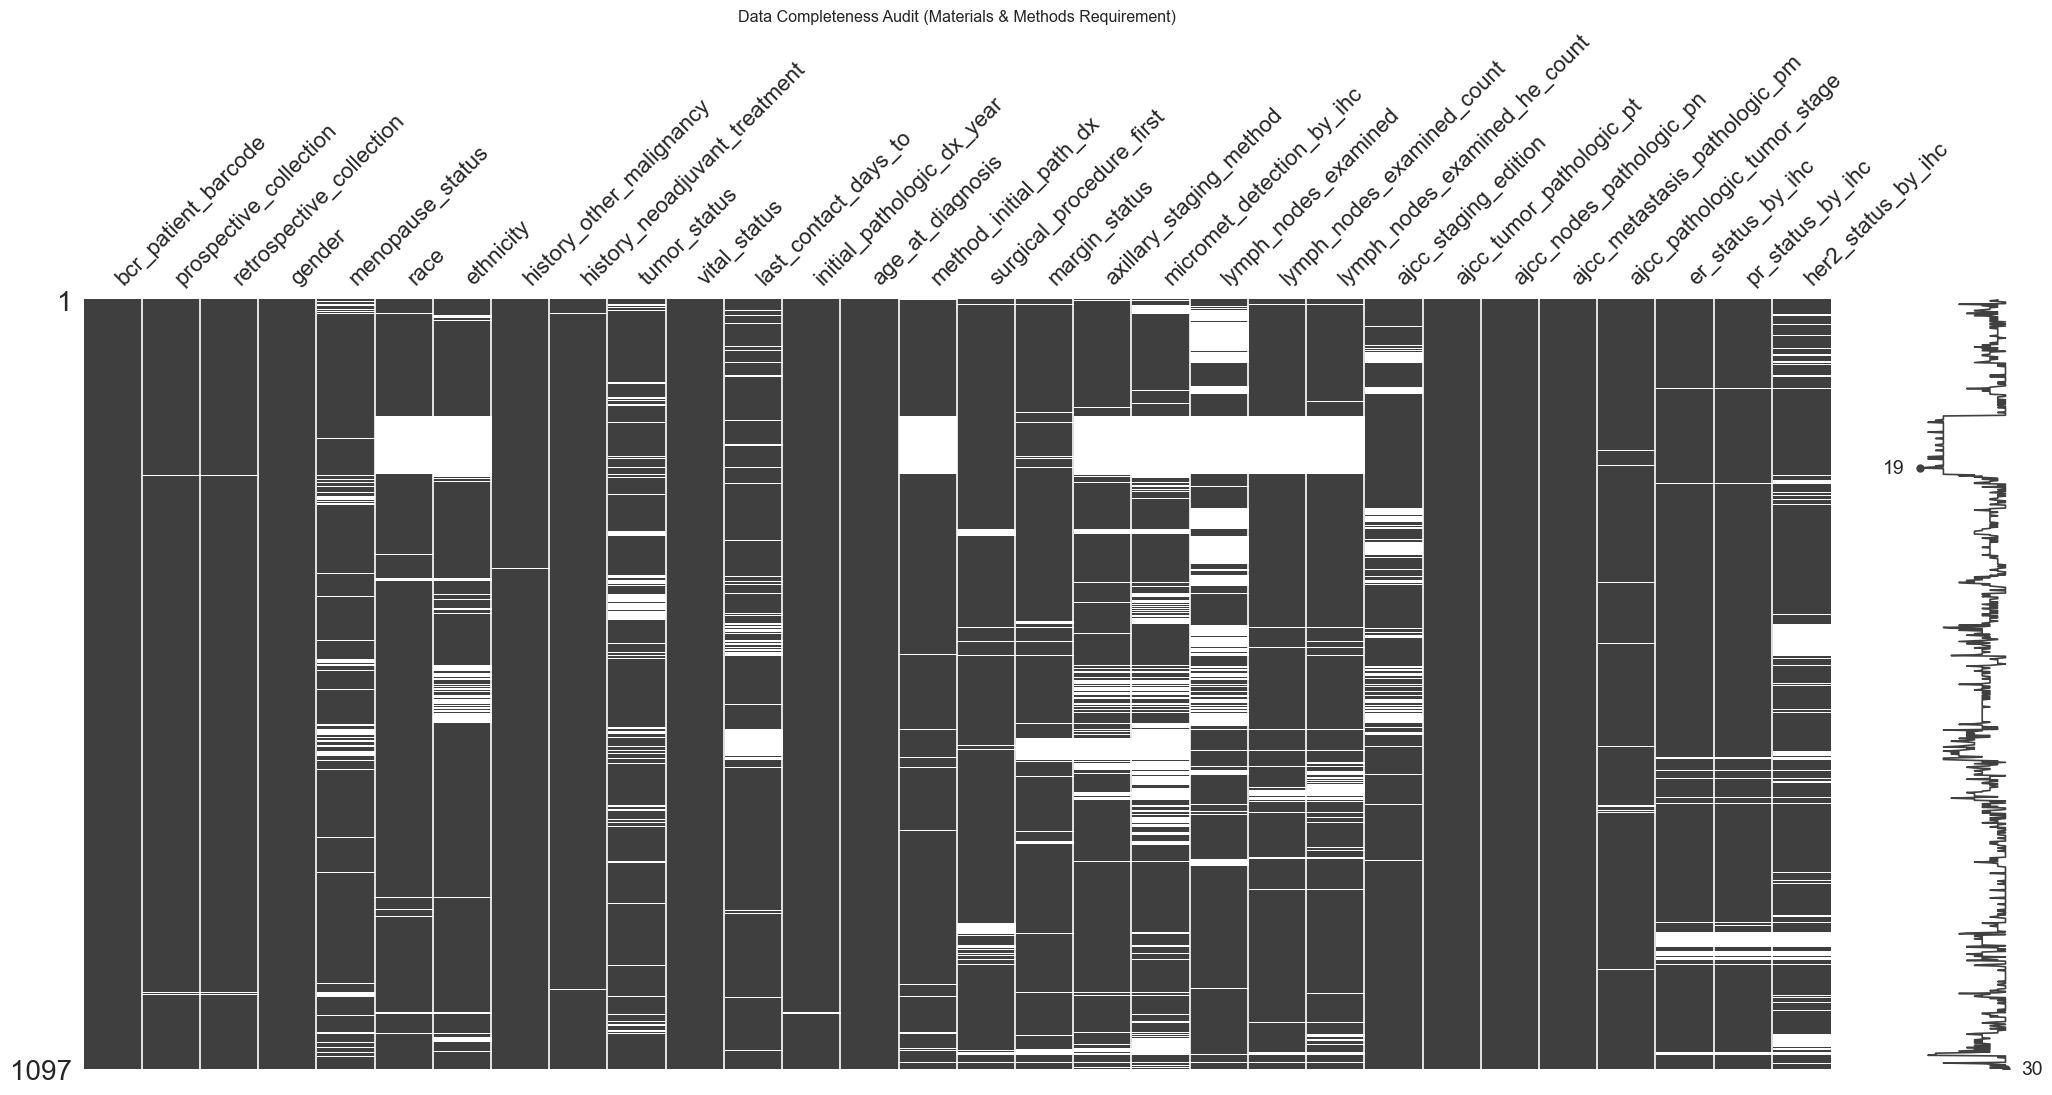

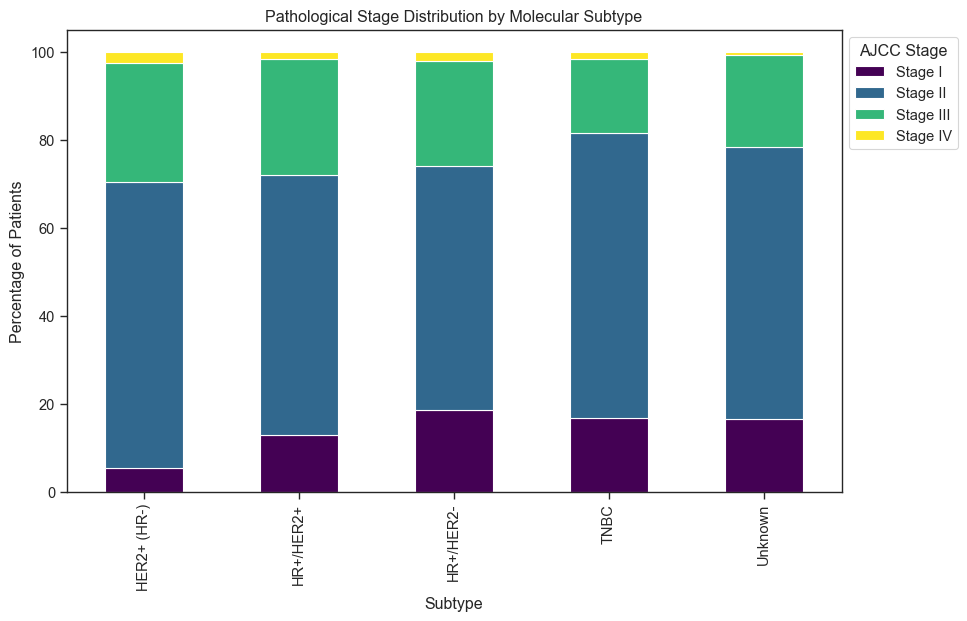


--- COX PROPORTIONAL HAZARDS MODEL ---
Model failed: Convergence halted due to matrix inversion problems. Suspicion is high collinearity. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-modelMatrix is singular.. (Likely due to low event count in this specific CSV slice)


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import CoxPHFitter
import missingno as msno # Useful for data quality audits

# 1. DATA QUALITY AUDIT (The 'Reviewer-Friendly' Step)
def audit_data_quality(df):
    plt.figure(figsize=(10, 6))
    msno.matrix(df.iloc[:, :30]) # Audit first 30 columns for missingness
    plt.title("Data Completeness Audit (Materials & Methods Requirement)")
    plt.show()

# 2. ADVANCED PATHOLOGICAL ANALYSIS
def analyze_pathology(df):
    # Simplify Stage for better visualization
    df['stage_simple'] = df['ajcc_pathologic_tumor_stage'].str.extract(r'(Stage [I|V]+)')
    
    # Cross-tabulation of Subtype vs Stage
    ct = pd.crosstab(df['Subtype'], df['stage_simple'], normalize='index') * 100
    
    ct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
    plt.title("Pathological Stage Distribution by Molecular Subtype")
    plt.ylabel("Percentage of Patients")
    plt.legend(title="AJCC Stage", bbox_to_anchor=(1,1))
    plt.show()

# 3. THE DOCTORAL STEP: COX PROPORTIONAL HAZARDS
def run_cox_model(df):
    print("\n--- COX PROPORTIONAL HAZARDS MODEL ---")
    # Preparing data for Cox: Must be numeric and no NaNs
    cox_data = df[['last_contact_days_to', 'event_observed', 'age_at_diagnosis', 'Subtype', 'stage_simple']].dropna()
    
    # Convert categorical to dummies
    cox_data = pd.get_dummies(cox_data, columns=['Subtype', 'stage_simple'], drop_first=True)
    
    cph = CoxPHFitter()
    try:
        cph.fit(cox_data, duration_col='last_contact_days_to', event_col='event_observed')
        cph.print_summary()  # This gives you Hazard Ratios and P-values
        
        # Plotting the Forest Plot (Essential for papers!)
        plt.figure(figsize=(10, 6))
        cph.plot()
        plt.title("Hazard Ratios for Clinical Features (Cox Model)")
        plt.show()
    except Exception as e:
        print(f"Model failed: {e}. (Likely due to low event count in this specific CSV slice)")

# Execute
audit_data_quality(df)
analyze_pathology(df)
run_cox_model(df)

C:\Users\USER\AppData\Local\Temp\ipykernel_19924\222290629.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Subtype', y='LNR', inner="quart", palette="muted")


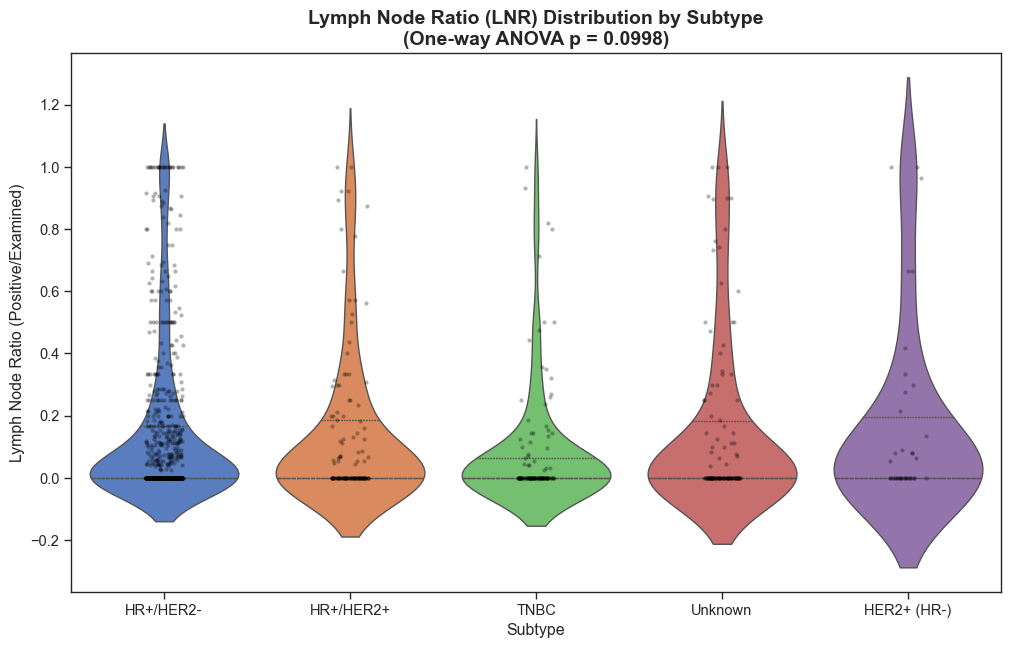

--- TABLE 1: CLINICAL CHARACTERISTICS BY MOLECULAR SUBTYPE ---
             age_at_diagnosis  lymph_nodes_examined_count    LNR    N
Subtype                                                              
HER2+ (HR-)              57.5                      12.633  0.169   38
HR+/HER2+                61.5                      11.051  0.141  126
HR+/HER2-                59.0                      10.600  0.149  699
TNBC                     53.5                      10.110  0.088  116
Unknown                  56.0                      10.540  0.153  118


In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway

# 1. Calculate Lymph Node Ratio (LNR) - A high-impact clinical metric
# LNR = (Positive Nodes / Total Nodes Examined)
# We handle division by zero or NaN
df['LNR'] = df['lymph_nodes_examined_he_count'] / df['lymph_nodes_examined_count']
df['LNR'] = df['LNR'].replace([np.inf, -np.inf], np.nan).fillna(0)

# 2. Advanced Visualization: LNR by Subtype
plt.figure(figsize=(12, 7))
sns.violinplot(data=df, x='Subtype', y='LNR', inner="quart", palette="muted")
sns.stripplot(data=df, x='Subtype', y='LNR', color="black", size=3, alpha=0.3)

# 3. Statistical Validation (ANOVA)
subtypes = df['Subtype'].unique()
group_data = [df[df['Subtype'] == s]['LNR'].dropna() for s in subtypes if s != 'Unknown']
f_stat, p_val = f_oneway(*group_data)

plt.title(f"Lymph Node Ratio (LNR) Distribution by Subtype\n(One-way ANOVA p = {p_val:.4f})", 
          fontsize=14, fontweight='bold')
plt.ylabel("Lymph Node Ratio (Positive/Examined)")
plt.show()

# 4. Professional Summary Table for your Thesis
clinical_summary = df.groupby('Subtype').agg({
    'age_at_diagnosis': 'median',
    'lymph_nodes_examined_count': 'mean',
    'LNR': 'mean',
    'bcr_patient_barcode': 'count'
}).rename(columns={'bcr_patient_barcode': 'N'})

print("--- TABLE 1: CLINICAL CHARACTERISTICS BY MOLECULAR SUBTYPE ---")
print(clinical_summary.round(3))